In [ ]:
# IPL Data Analysis (2008–2026)

### Data Analytics Project

*Tools Used:*
- Python
- Pandas
- Matplotlib

*Objective:*
Analyze IPL data from 2008–2026 to identify team performance, venue trends, toss impact, and season-wise insights.

In [ ]:
## Project Objectives

The main objectives of this project are:

- Analyze IPL matches from 2008–2026
- Identify the most successful teams
- Study toss impact on match outcomes
- Analyze venue performance
- Explore season-wise trends
- Create visualizations for insights

In [ ]:
## Dataset Description

This dataset contains IPL match information from 2008–2026 including:

- Teams
- Match Winners
- Toss Winners
- Venues
- Seasons
- Match Results

Source: Kaggle IPL Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load your upload dataset
df = pd.read_csv("/ipl_matches_data.csv")
# Print the size of the dataset and the exact columns
print ("Dataset ready")
print(f"Total Rows :{df.shape[0]} ,Total Columns : {df.shape[1]}")
print("\n Your columns are ")
print(list(df.columns))

Dataset ready
Total Rows :1212 ,Total Columns : 23

 Your columns are 
['match_id', 'season_id', 'balls_per_over', 'city', 'match_date', 'event_name', 'match_number', 'gender', 'match_type', 'format', 'overs', 'season', 'team_type', 'venue', 'toss_winner', 'team1', 'team2', 'toss_decision', 'match_winner', 'win_by_runs', 'win_by_wickets', 'result', 'player_of_match']


In [2]:
# View the top 5 rows of your data
df.head()

,match_id,season_id,balls_per_over,city,match_date,event_name,match_number,gender,match_type,format,...,venue,toss_winner,team1,team2,toss_decision,match_winner,win_by_runs,win_by_wickets,result,player_of_match
0,335982,2008,6,Bangalore,2008-04-18,Indian Premier League,1.0,male,T20,T20,...,M Chinnaswamy Stadium,1,1,6,field,6,140.0,NaN,win,46.0
1,1082591,2017,6,Hyderabad,2017-04-05,Indian Premier League,1.0,male,T20,T20,...,"Rajiv Gandhi International Stadium, Uppal",1,2,1,field,2,35.0,NaN,win,15.0
2,1082592,2017,6,Pune,2017-04-06,Indian Premier League,2.0,male,T20,T20,...,Maharashtra Cricket Association Stadium,4,4,3,field,4,NaN,7.0,win,36.0
3,1082593,2017,6,Rajkot,2017-04-07,Indian Premier League,3.0,male,T20,T20,...,Saurashtra Cricket Association Stadium,6,5,6,field,6,NaN,10.0,win,57.0
4,1082594,2017,6,Indore,2017-04-08,Indian Premier League,4.0,male,T20,T20,...,Holkar Cricket Stadium,494,494,4,field,494,NaN,6.0,win,71.0


In [3]:
print("Missing Values Per Column ")
print(df.isnull().sum())
print("\n Basic Statistical Summary ")
df.describe(include ='all')

Missing Values Per Column 
match_id             0
season_id            0
balls_per_over       0
city                51
match_date           0
event_name           0
match_number        70
gender               0
match_type           0
format               0
overs                0
season               0
team_type            0
venue                0
toss_winner          0
team1                0
team2                0
toss_decision        0
match_winner         0
win_by_runs        666
win_by_wickets     571
result               0
player_of_match      9
dtype: int64

 Basic Statistical Summary 


,match_id,season_id,balls_per_over,city,match_date,event_name,match_number,gender,match_type,format,...,venue,toss_winner,team1,team2,toss_decision,match_winner,win_by_runs,win_by_wickets,result,player_of_match
count,1.212000e+03,1212.000000,1212.0,1161,1212,1212,1142.000000,1212,1212,1212,...,1212,1212.000000,1212.000000,1212.000000,1212,1212.000000,546.000000,641.000000,1212,1203.000000
unique,NaN,NaN,NaN,37,920,1,NaN,1,1,1,...,59,NaN,NaN,NaN,2,NaN,NaN,NaN,3,NaN
top,NaN,NaN,NaN,Mumbai,2017-04-14,Indian Premier League,NaN,male,T20,T20,...,Eden Gardens,NaN,NaN,NaN,field,NaN,NaN,NaN,win,NaN
freq,NaN,NaN,NaN,185,2,1212,NaN,1212,1212,1212,...,77,NaN,NaN,NaN,800,NaN,NaN,NaN,1187,NaN
mean,9.616860e+05,2017.018152,6.0,NaN,NaN,NaN,31.328371,NaN,NaN,NaN,...,NaN,175.825083,180.485149,184.131188,NaN,170.292079,30.608059,6.182527,NaN,3508.096426
std,3.905328e+05,5.439222,0.0,NaN,NaN,NaN,18.397497,NaN,NaN,NaN,...,NaN,267.640775,275.288484,275.467446,NaN,250.118969,27.010366,1.837816,NaN,6456.038968
min,3.359820e+05,2008.000000,6.0,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,...,NaN,1.000000,1.000000,1.000000,NaN,1.000000,1.000000,1.000000,NaN,1.000000
25%,5.483628e+05,2012.000000,6.0,NaN,NaN,NaN,16.000000,NaN,NaN,NaN,...,NaN,3.000000,3.000000,3.000000,NaN,3.000000,11.000000,5.000000,NaN,49.000000
50%,1.082620e+06,2017.000000,6.0,NaN,NaN,NaN,31.000000,NaN,NaN,NaN,...,NaN,129.000000,129.000000,129.000000,NaN,129.000000,22.000000,6.000000,NaN,332.000000
75%,1.304079e+06,2022.000000,6.0,NaN,NaN,NaN,46.000000,NaN,NaN,NaN,...,NaN,252.000000,252.000000,252.000000,NaN,252.000000,42.000000,7.000000,NaN,4104.000000


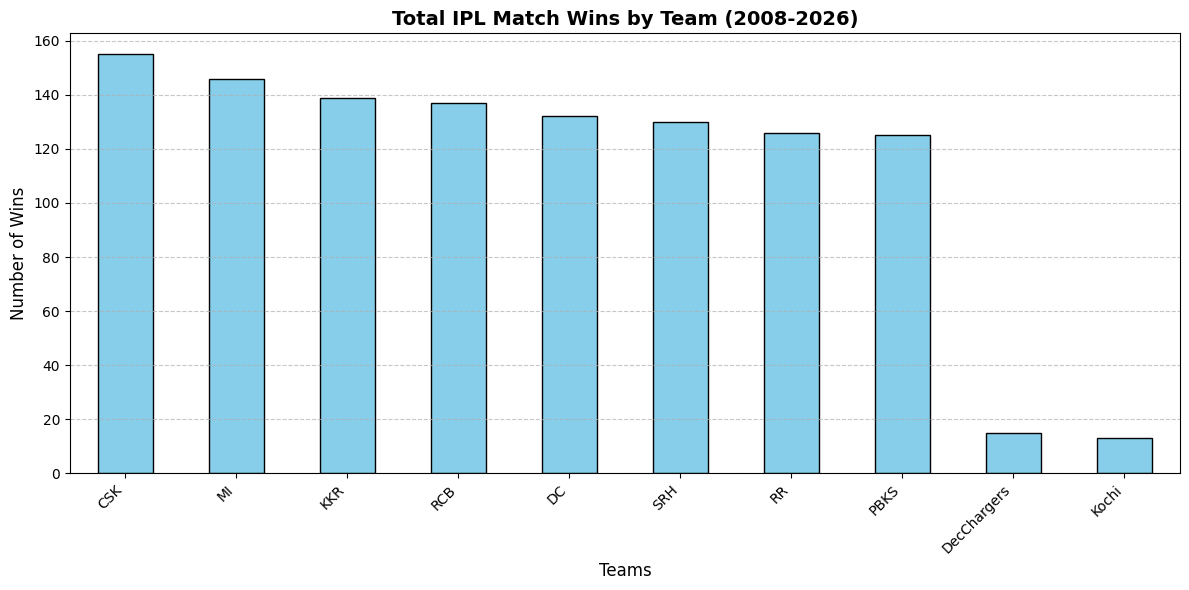

In [23]:
 # 1. Dictionary to translate team IDs to Team Names
team_names_map = {
    3: 'CSK', 129: 'MI', 1: 'KKR', 6: 'RCB',
    2: 'DC', 494: 'SRH', 252: 'RR', 134: 'PBKS',
    515: 'GT', 514: 'LSG', 4: 'DecChargers', 5: 'Kochi',
    419: 'RPS', 414: 'GL'
}

# 2. Convert numbers to names
clean_winner_names = df['match_winner'].map(team_names_map)

# 3. Count wins for each team name
team_wins = clean_winner_names.value_counts()

# 4. Plotting the bar chart
plt.figure(figsize=(12, 6))
team_wins.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Total IPL Match Wins by Team (2008-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Teams', fontsize=12)
plt.ylabel('Number of Wins', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
## Observation

Mumbai Indians and Chennai Super Kings have the highest number of wins in IPL history.

This suggests strong long-term team performance and consistency across seasons.

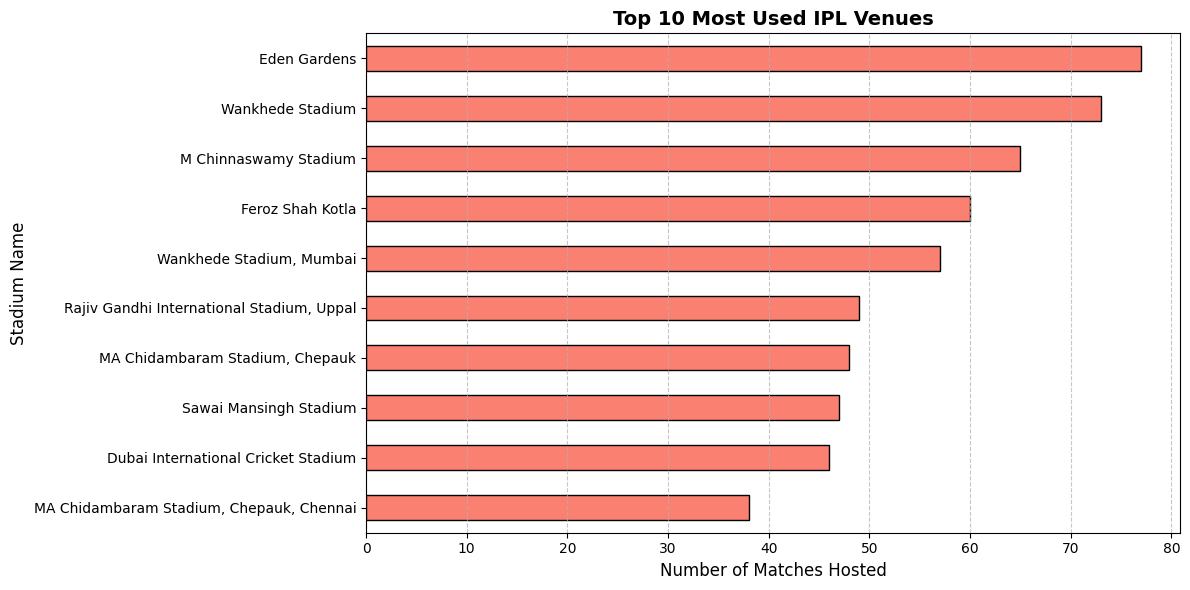

In [17]:
# Get top 10 venues
top_venues = df['venue'].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_venues.plot(kind='barh', color='salmon', edgecolor='black').invert_yaxis()

plt.title('Top 10 Most Used IPL Venues', fontsize=14, fontweight='bold')
plt.xlabel('Number of Matches Hosted', fontsize=12)
plt.ylabel('Stadium Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

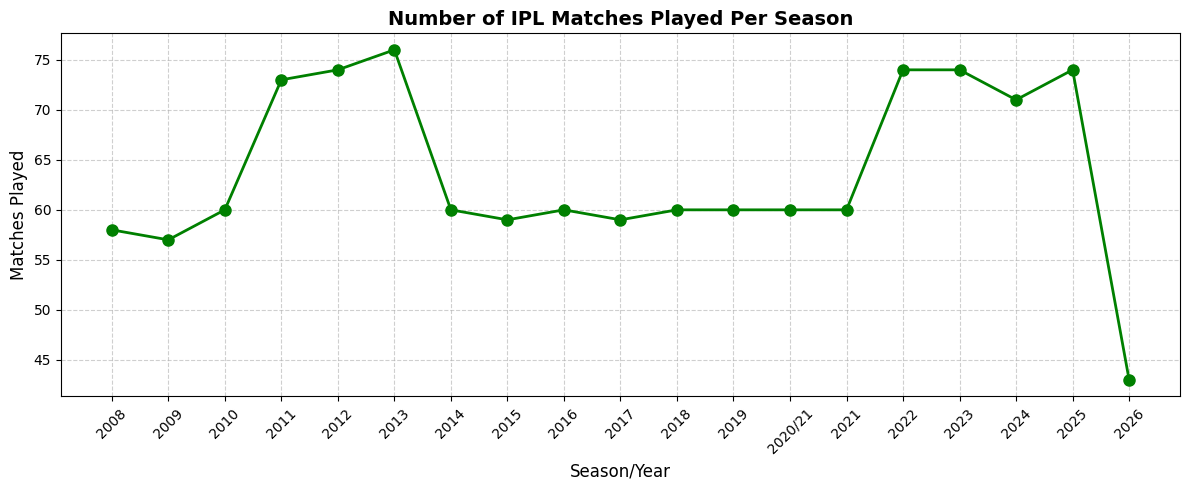

In [19]:
# Count matches  per season and sort them chronologically
matches_per_season = df['season'].value_counts().sort_index()
plt.figure(figsize=(12,5))
plt.plot(matches_per_season.index,matches_per_season.values, marker ='o', color ='green' ,linewidth = 2, markersize = 8)
plt.title('Number of IPL Matches Played Per Season', fontsize =14 , fontweight ='bold')
plt.xlabel('Season/Year' , fontsize = 12)
plt.ylabel('Matches Played', fontsize = 12)
plt.xticks(rotation = 45)
plt.grid(True , linestyle = '--' , alpha = 0.6)
plt.tight_layout()
plt.show()

In [22]:
# Check how many times the team that won the toss also won the match
toss_and_match_winner = df[df['toss_winner'] == df['match_winner']]

# Calculate the percentage
toss_win_percentage = (len(toss_and_match_winner) / len(df)) * 100

print("--- THE TOSS FACTOR INSIGHT ---")
print(f"Total Matches analyzed: {len(df)}")
print(f"Matches won by the Toss Winner: {len(toss_and_match_winner)}")
print(f"Percentage of matches won after winning the toss: {toss_win_percentage:.2f}%")

# Quick decision insight
print("\n--- WHAT TEAMS DO AFTER WINNING TOSS ---")
print(df['toss_decision'].value_counts(normalize=True) * 100)

--- THE TOSS FACTOR INSIGHT ---
Total Matches analyzed: 1212
Matches won by the Toss Winner: 626
Percentage of matches won after winning the toss: 51.65%

--- WHAT TEAMS DO AFTER WINNING TOSS ---
toss_decision
field    66.006601
bat      33.993399
Name: proportion, dtype: float64


In [ ]:
# Conclusion

This project analyzed IPL data from 2008–2026 using Python, Pandas, and Matplotlib.

The analysis identified team performance trends, venue patterns, and the impact of toss decisions on match outcomes.

The project demonstrates skills in:

- Data Cleaning
- Exploratory Data Analysis
- Data Visualization
- Insight Generation